<a href="https://colab.research.google.com/github/bikashmac/diss/blob/main/ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost lightgbm

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                           f1_score, confusion_matrix, classification_report,
                           roc_auc_score, roc_curve, auc)
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                            BaggingClassifier, StackingClassifier, VotingClassifier)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')



In [21]:
df = pd.read_csv('water_potability.csv')

print(f"Number of features: {df.shape[1] - 1}")
print(f"Number of samples: {df.shape[0]}")

Number of features: 9
Number of samples: 3276


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [23]:
display(df.head())

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [24]:
df.infer_objects()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0
...,...,...,...,...,...,...,...,...,...,...
3271,4.668102,193.681735,47580.991603,7.166639,359.948574,526.424171,13.894419,66.687695,4.435821,1
3272,7.808856,193.553212,17329.802160,8.061362,NaN,392.449580,19.903225,NaN,2.798243,1
3273,9.419510,175.762646,33155.578218,7.350233,NaN,432.044783,11.039070,69.845400,3.298875,1
3274,5.126763,230.603758,11983.869376,6.303357,NaN,402.883113,11.168946,77.488213,4.708658,1


In [25]:
print("Missing Values Analysis:")
missing_df = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage': (df.isnull().sum() / len(df)) * 100
})
print(missing_df)

Missing Values Analysis:
                 Missing Values  Percentage
ph                          491   14.987790
Hardness                      0    0.000000
Solids                        0    0.000000
Chloramines                   0    0.000000
Sulfate                     781   23.840049
Conductivity                  0    0.000000
Organic_carbon                0    0.000000
Trihalomethanes             162    4.945055
Turbidity                     0    0.000000
Potability                    0    0.000000


In [26]:
# Target distribution
print("Target Variable Distribution:")
target_counts = df['Potability'].value_counts()
print(f"Non-Potable (0): {target_counts[0]} samples ({target_counts[0]/len(df)*100:.2f}%)")
print(f"Potable (1): {target_counts[1]} samples ({target_counts[1]/len(df)*100:.2f}%)")
print(f"Class Imbalance Ratio: {target_counts[0]/target_counts[1]:.2f}:1")

Target Variable Distribution:
Non-Potable (0): 1998 samples (60.99%)
Potable (1): 1278 samples (39.01%)
Class Imbalance Ratio: 1.56:1


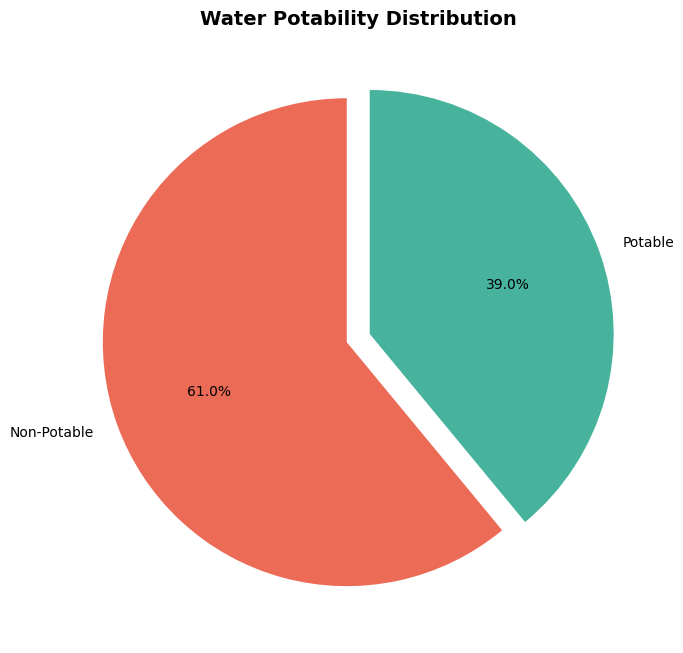

In [27]:
fig, ax = plt.subplots(figsize=(7, 7))
colors = ['#EC6B56', '#47B39C']
ax.pie(target_counts.values, labels=['Non-Potable', 'Potable'],
              autopct='%1.1f%%', colors=colors, startangle=90, explode=(0.05, 0.05))
ax.set_title('Water Potability Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

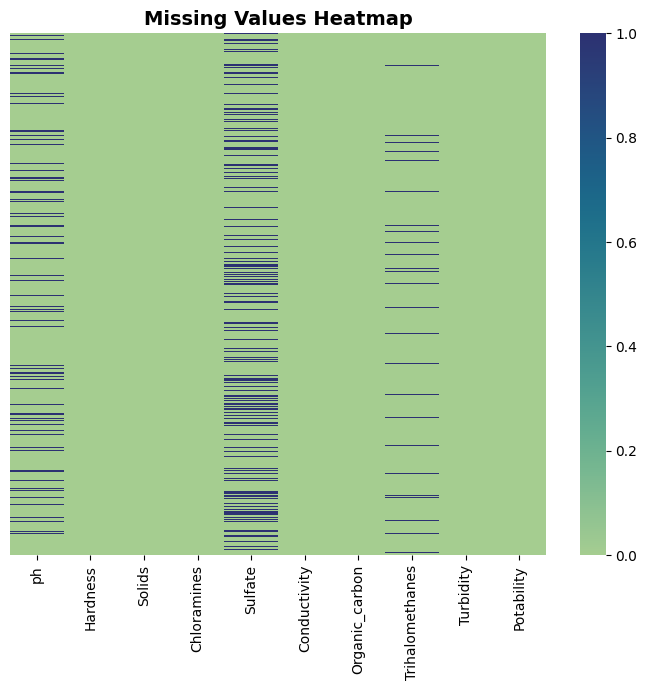

In [28]:
fig, ax = plt.subplots(figsize=(7, 7))
sns.heatmap(df.isnull(), yticklabels=False, cbar=True, cmap='crest')
ax.set_title('Missing Values Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Data preprocessing balancing and expanding**

In [29]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from sklearn.impute import SimpleImputer

In [30]:
X = df.drop('Potability', axis=1)
y = df['Potability']

In [31]:
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)
X_imputed = pd.DataFrame(X_imputed, columns=X.columns)

In [32]:
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)
X_imputed = pd.DataFrame(X_imputed, columns=X.columns)

print("Missing Values Analysis after Imputation:")
missing_df_after_imputation = pd.DataFrame({
    'Missing Values': X_imputed.isnull().sum(),
    'Percentage': (X_imputed.isnull().sum() / len(X_imputed)) * 100
})
print(missing_df_after_imputation)

Missing Values Analysis after Imputation:
                 Missing Values  Percentage
ph                            0         0.0
Hardness                      0         0.0
Solids                        0         0.0
Chloramines                   0         0.0
Sulfate                       0         0.0
Conductivity                  0         0.0
Organic_carbon                0         0.0
Trihalomethanes               0         0.0
Turbidity                     0         0.0


In [33]:
smote = SMOTE(
    sampling_strategy=1.0,
    random_state=42
)

X_smote, y_smote = smote.fit_resample(X_imputed, y)

print("\nAfter SMOTE:")
print(pd.Series(y_smote).value_counts())


After SMOTE:
Potability
0    1998
1    1998
Name: count, dtype: int64


In [34]:

# Expanding Dataset
df_smote = pd.DataFrame(X_smote, columns=X.columns)
df_smote['Potability'] = y_smote

# Desired size
TARGET_SIZE = 10000
half = TARGET_SIZE // 2

# Separate classes
df_0 = df_smote[df_smote['Potability'] == 0]
df_1 = df_smote[df_smote['Potability'] == 1]

# Sample equally
df_0_sampled = df_0.sample(half, replace=True, random_state=42)
df_1_sampled = df_1.sample(half, replace=True, random_state=42)

# Combine & shuffle
final_df = pd.concat([df_0_sampled, df_1_sampled])
final_df = final_df.sample(frac=1, random_state=42).reset_index(drop=True)



In [35]:
print("dataset shape after expanding:", final_df.shape)
print(final_df['Potability'].value_counts())

dataset shape after expanding: (10000, 10)
Potability
1    5000
0    5000
Name: count, dtype: int64


In [36]:
print("Target Variable Distribution:")
final_target_counts = final_df['Potability'].value_counts()
print(f"Non-Potable (0): {final_target_counts[0]} samples ({final_target_counts[0]/len(df)*100:.2f}%)")
print(f"Potable (1): {final_target_counts[1]} samples ({final_target_counts[1]/len(df)*100:.2f}%)")
print(f"Class Imbalance Ratio: {final_target_counts[0]/final_target_counts[1]:.2f}:1")

Target Variable Distribution:
Non-Potable (0): 5000 samples (152.63%)
Potable (1): 5000 samples (152.63%)
Class Imbalance Ratio: 1.00:1


In [37]:
display(final_df.tail())

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
9995,5.324641,142.806978,728.750830,8.403316,333.073546,496.997602,15.174664,60.077852,3.652003,1
9996,7.703177,229.635145,23641.983503,6.974582,310.311378,422.448767,10.718478,48.163920,3.301475,1
9997,6.617862,174.280566,33245.630587,7.022187,326.168480,479.920538,15.918912,60.339794,4.601351,1
9998,5.166226,135.712166,12060.009527,8.637098,333.073546,362.217258,11.185554,76.067064,4.608319,0
9999,5.869398,139.722113,11010.751551,5.369129,339.188989,447.983419,10.688518,88.603945,3.337511,1


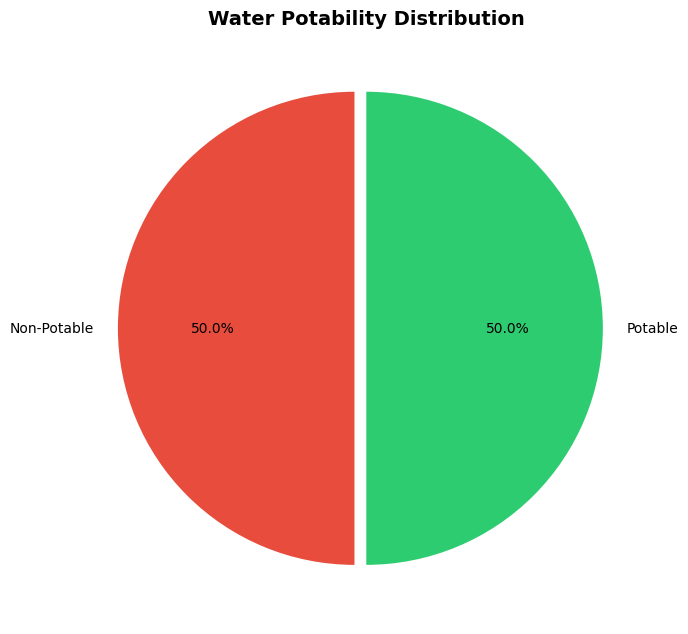

In [38]:
#distribution after preprocessing
final_target_counts = final_df['Potability'].value_counts()

plt.figure(figsize=(7, 7))
pie_colors = ['#E74C3C', '#2ECC71']  # red, green
plt.pie(final_target_counts.values,
        labels=['Non-Potable', 'Potable'],
        autopct='%1.1f%%',
        colors=pie_colors,
        startangle=90,
        explode=[0.05, 0.0])
plt.title('Water Potability Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


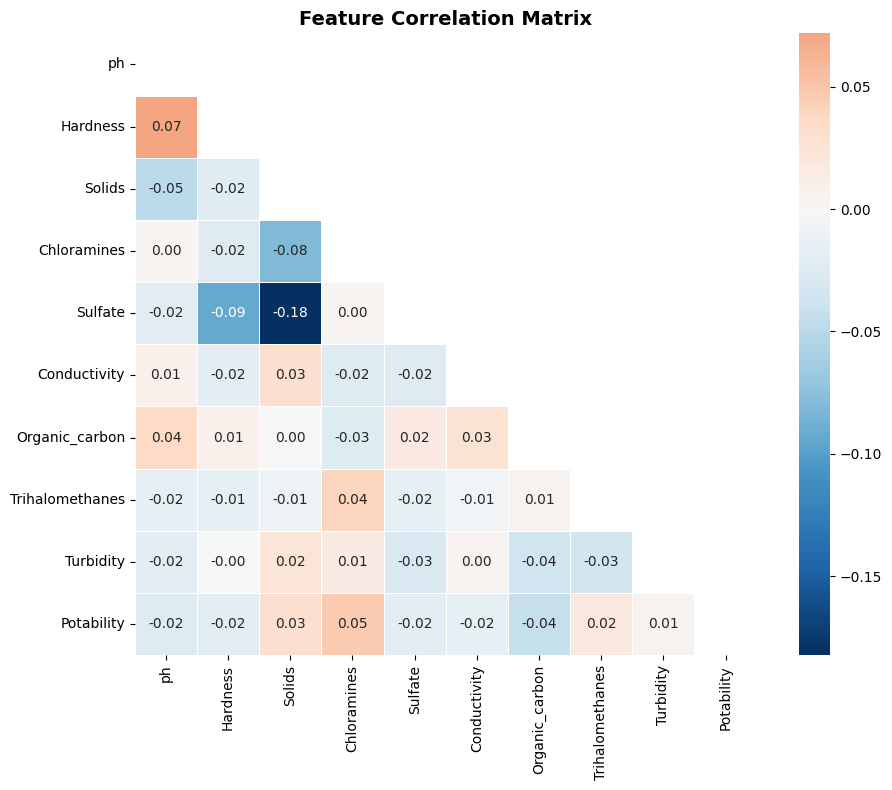

In [39]:
plt.figure(figsize=(10, 8))
correlation_matrix = final_df.corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


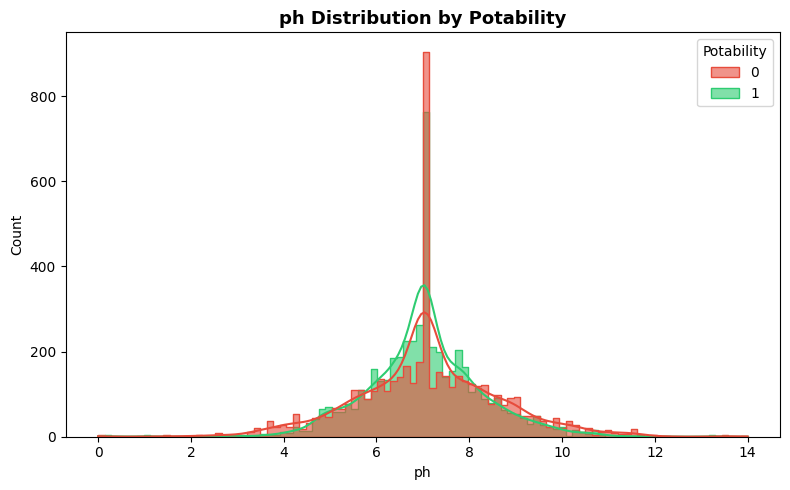

In [40]:
plt.figure(figsize=(8, 5))
sns.histplot(data=final_df, x='ph', hue='Potability', kde=True,
             element='step', alpha=0.6,
             palette={0:'#E74C3C', 1:'#2ECC71'})
plt.title('ph Distribution by Potability', fontsize=13, fontweight='bold')
plt.xlabel('ph')
plt.tight_layout()
plt.show()


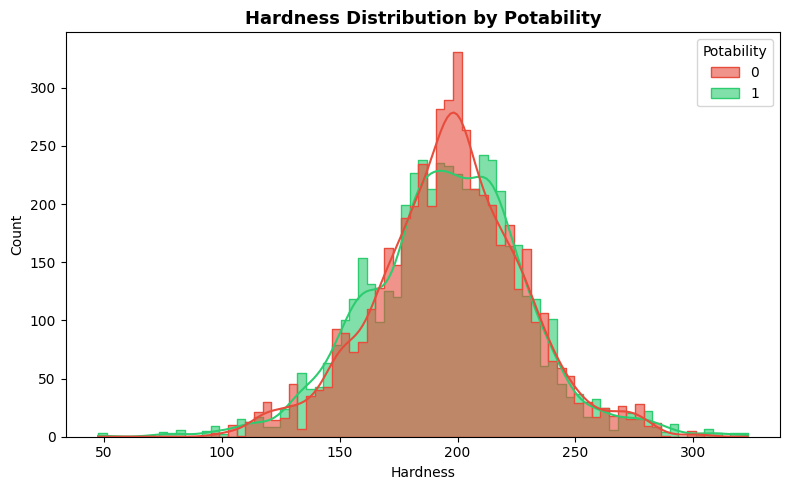

In [41]:
plt.figure(figsize=(8, 5))
sns.histplot(data=final_df, x='Hardness', hue='Potability', kde=True,
             element='step', alpha=0.6,
             palette={0:'#E74C3C', 1:'#2ECC71'})
plt.title('Hardness Distribution by Potability', fontsize=13, fontweight='bold')
plt.xlabel('Hardness')
plt.tight_layout()
plt.show()


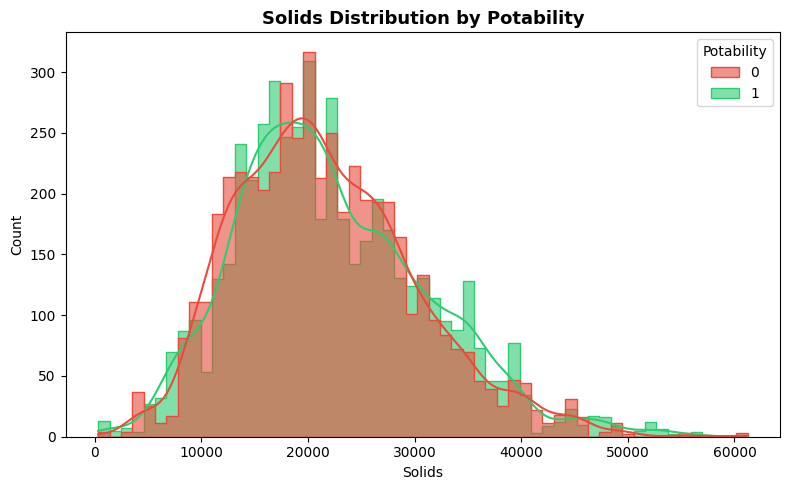

In [42]:
plt.figure(figsize=(8, 5))
sns.histplot(data=final_df, x='Solids', hue='Potability', kde=True,
             element='step', alpha=0.6,
             palette={0:'#E74C3C', 1:'#2ECC71'})
plt.title('Solids Distribution by Potability', fontsize=13, fontweight='bold')
plt.xlabel('Solids')
plt.tight_layout()
plt.show()


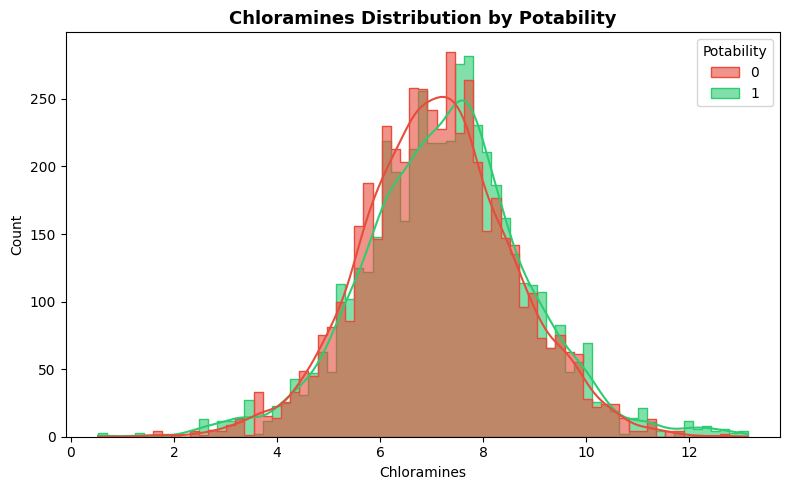

In [43]:
plt.figure(figsize=(8, 5))
sns.histplot(data=final_df, x='Chloramines', hue='Potability', kde=True,
             element='step', alpha=0.6,
             palette={0:'#E74C3C', 1:'#2ECC71'})
plt.title('Chloramines Distribution by Potability', fontsize=13, fontweight='bold')
plt.xlabel('Chloramines')
plt.tight_layout()
plt.show()


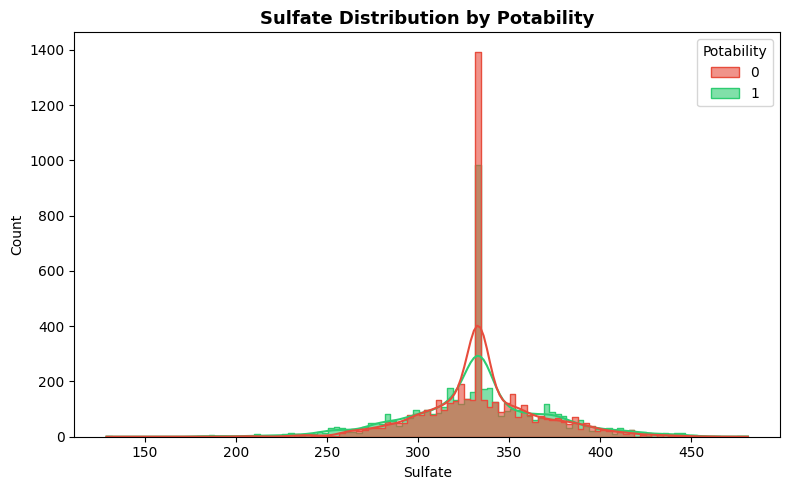

In [44]:
plt.figure(figsize=(8, 5))
sns.histplot(data=final_df, x='Sulfate', hue='Potability', kde=True,
             element='step', alpha=0.6,
             palette={0:'#E74C3C', 1:'#2ECC71'})
plt.title('Sulfate Distribution by Potability', fontsize=13, fontweight='bold')
plt.xlabel('Sulfate')
plt.tight_layout()
plt.show()


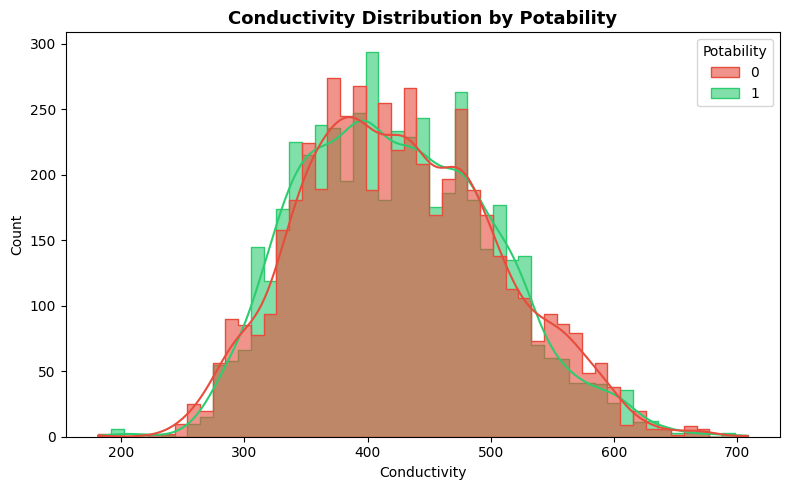

In [45]:
plt.figure(figsize=(8, 5))
sns.histplot(data=final_df, x='Conductivity', hue='Potability', kde=True,
             element='step', alpha=0.6,
             palette={0:'#E74C3C', 1:'#2ECC71'})
plt.title('Conductivity Distribution by Potability', fontsize=13, fontweight='bold')
plt.xlabel('Conductivity')
plt.tight_layout()
plt.show()


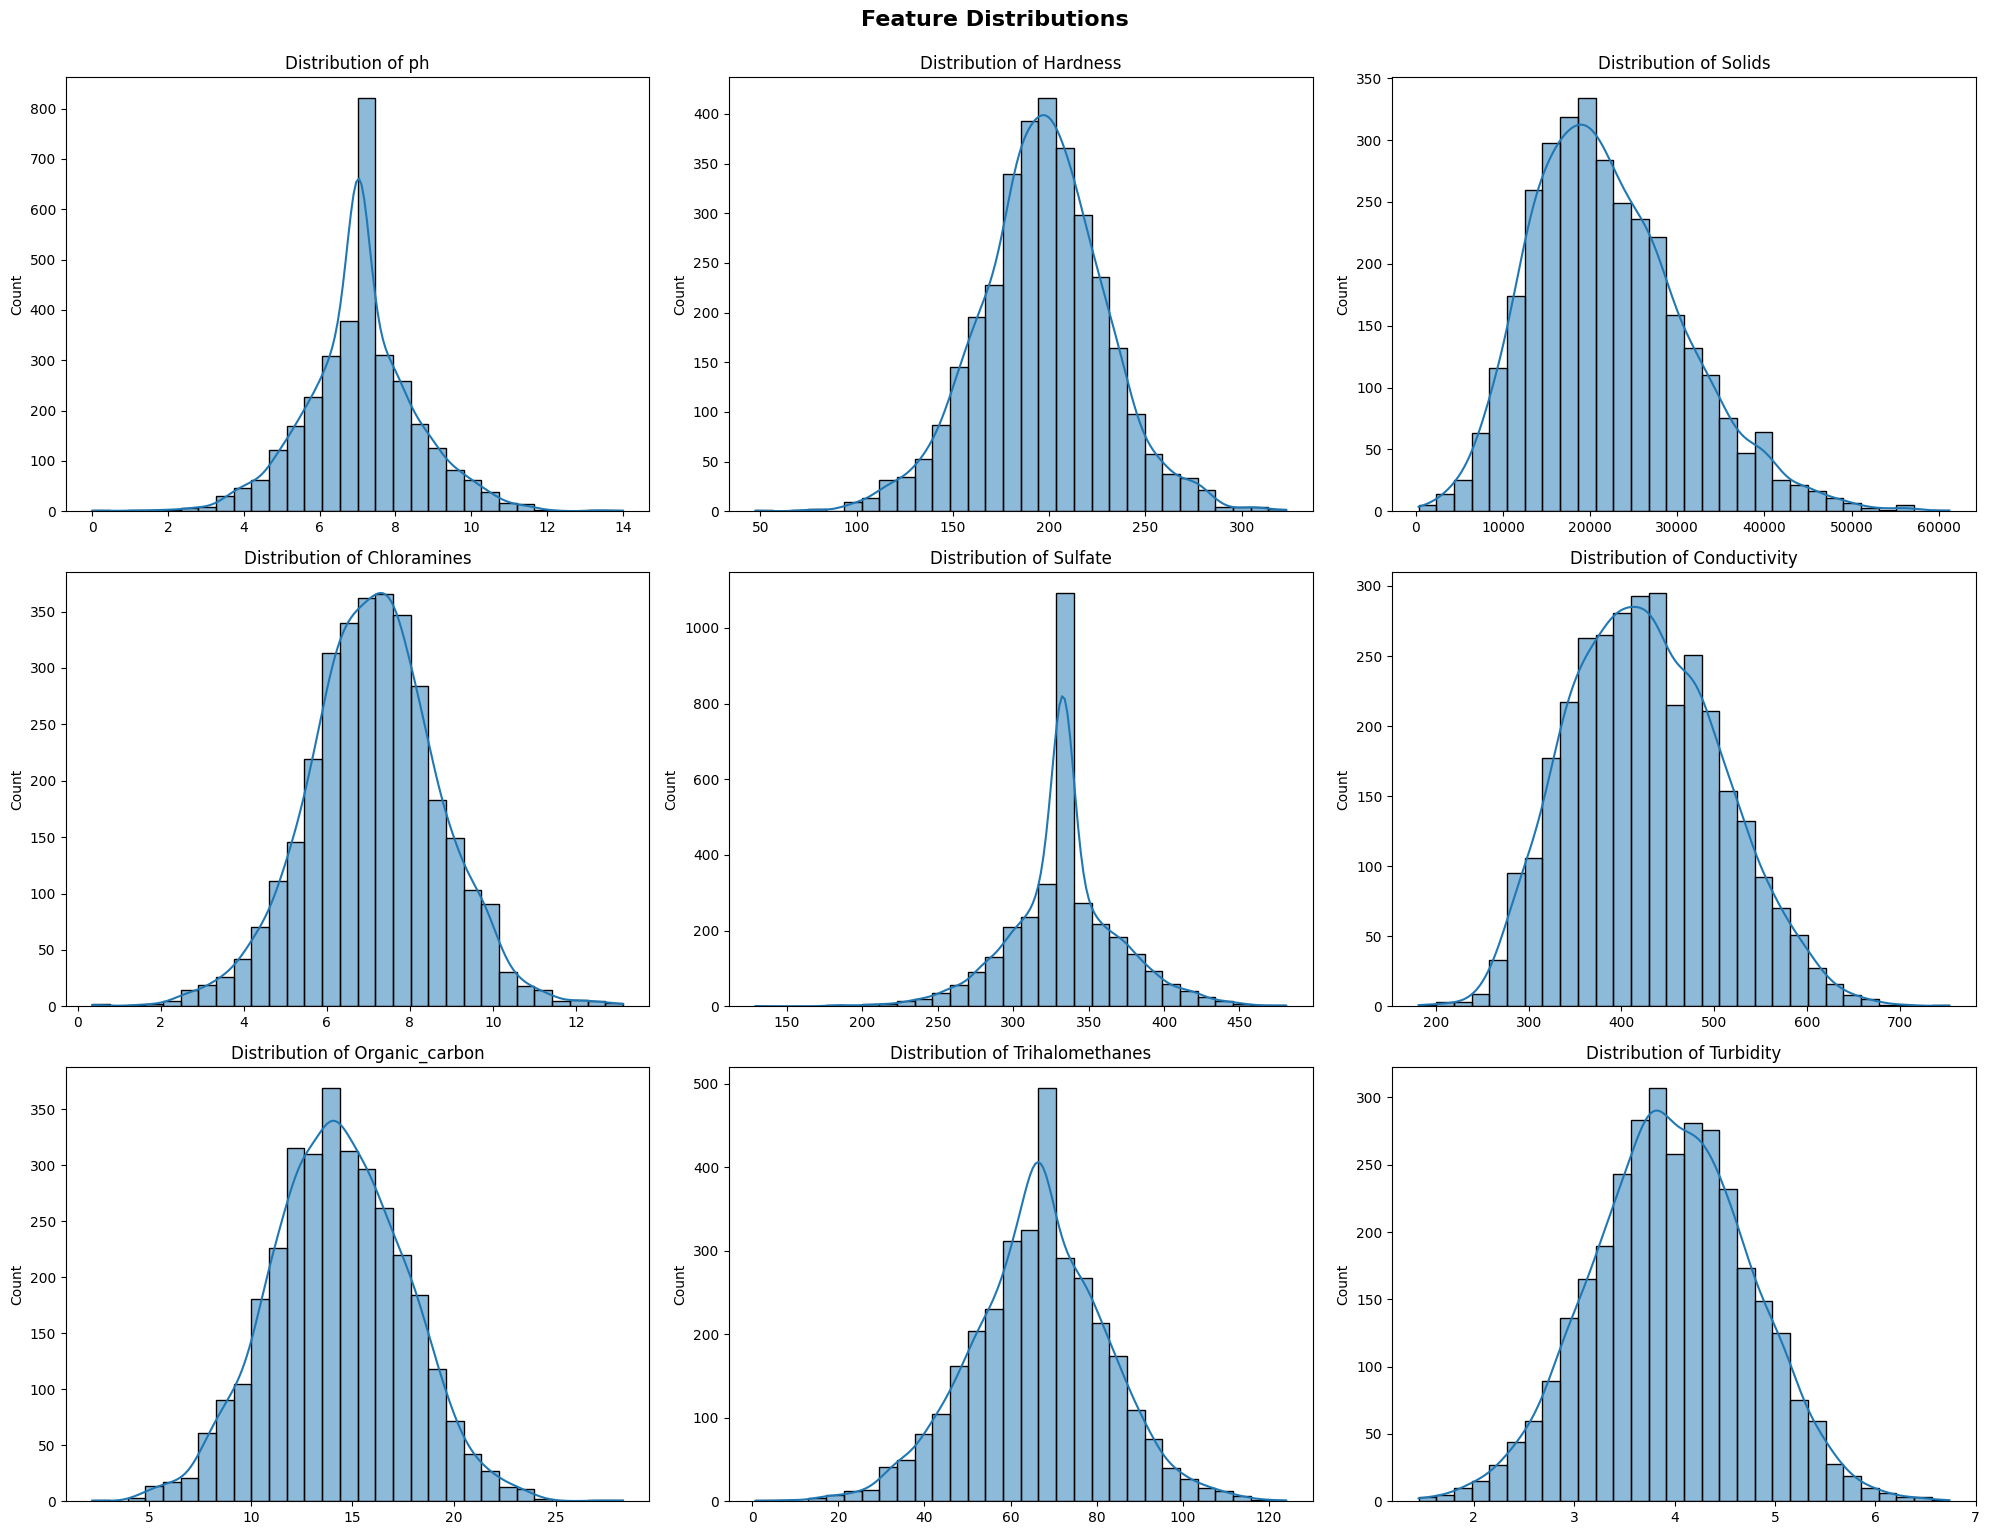

In [46]:
# Verify feature distributions
fig, axes = plt.subplots(3, 3, figsize=(20,15 ))
features = X_imputed.columns
num_cols = 3

for i, feature in enumerate(features):

    ax = axes[i // num_cols, i % num_cols]
    sns.histplot(data=X_imputed, x=feature, kde=True, ax=ax, bins=30)
    ax.set_title(f'Distribution of {feature}', fontsize=12)
    ax.set_xlabel('')

plt.tight_layout()
plt.suptitle('Feature Distributions', fontsize=16, fontweight='bold', y=1.02)
plt.show()

In [47]:

# Check for outliers using IQR method
for column in final_df.select_dtypes(include=[np.number]).columns:
    if column != 'Potability':
        Q1 = final_df[column].quantile(0.25)
        Q3 = final_df[column].quantile(0.75)
        IQR = Q3 - Q1
        outliers = ((final_df[column] < (Q1 - 1.5 * IQR)) | (final_df[column] > (Q3 + 1.5 * IQR))).sum()
        print(f"{column}: {outliers} outliers ({outliers/len(final_df)*100:.2f}%)")

ph: 451 outliers (4.51%)
Hardness: 249 outliers (2.49%)
Solids: 150 outliers (1.50%)
Chloramines: 213 outliers (2.13%)
Sulfate: 759 outliers (7.59%)
Conductivity: 30 outliers (0.30%)
Organic_carbon: 64 outliers (0.64%)
Trihalomethanes: 162 outliers (1.62%)
Turbidity: 67 outliers (0.67%)


In [48]:
df_processed = final_df.copy()

In [49]:
# Createing interaction features
X_final = final_df.drop('Potability', axis=1)
X_engineered = X_final.copy()
X_engineered['ph_solids'] = X_engineered['ph'] * X_engineered['Solids']
X_engineered['hardness_sulfate'] = X_engineered['Hardness'] * X_engineered['Sulfate']
X_engineered['chloramines_conductivity'] = X_engineered['Chloramines'] * X_engineered['Conductivity']
X_engineered['organic_tds'] = X_engineered['Organic_carbon'] * X_engineered['Solids'] / 1000
X_engineered['trihalomethanes_ratio'] = X_engineered['Trihalomethanes'] / (X_engineered['Chloramines'] + 1)

In [50]:
print(f"Original features: {X.shape[1]}")
print(f"Features after engineering: {X_engineered.shape[1]}")
print(f"New features created: {X_engineered.shape[1] - X.shape[1]}")

Original features: 9
Features after engineering: 14
New features created: 5


In [51]:
# Applying Robust Scaling
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_engineered)
X_scaled = pd.DataFrame(X_scaled, columns=X_engineered.columns)

In [52]:
X_final = final_df.drop('Potability', axis=1)
y_final = final_df['Potability']

In [53]:
# Spliting data into training (80%) and testing (20%)

X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(
    X_scaled, y_final,
    test_size=0.2,
    random_state=42,
    stratify=y_final
)

print(f"Training set (features): {X_train_final.shape[0]} samples ({X_train_final.shape[0]/len(X_scaled)*100:.1f}%)")
print(f"Testing set (features): {X_test_final.shape[0]} samples ({X_test_final.shape[0]/len(X_scaled)*100:.1f}%)")
print(f"Training set (target): {y_train_final.shape[0]} samples")
print(f"Testing set (target): {y_test_final.shape[0]} samples")
print(f"Training potability rate: {y_train_final.mean():.2%}")
print(f"Testing potability rate: {y_test_final.mean():.2%}")
print(f"Training features count: {X_train_final.shape[1]}")

Training set (features): 8000 samples (80.0%)
Testing set (features): 2000 samples (20.0%)
Training set (target): 8000 samples
Testing set (target): 2000 samples
Training potability rate: 50.00%
Testing potability rate: 50.00%
Training features count: 14


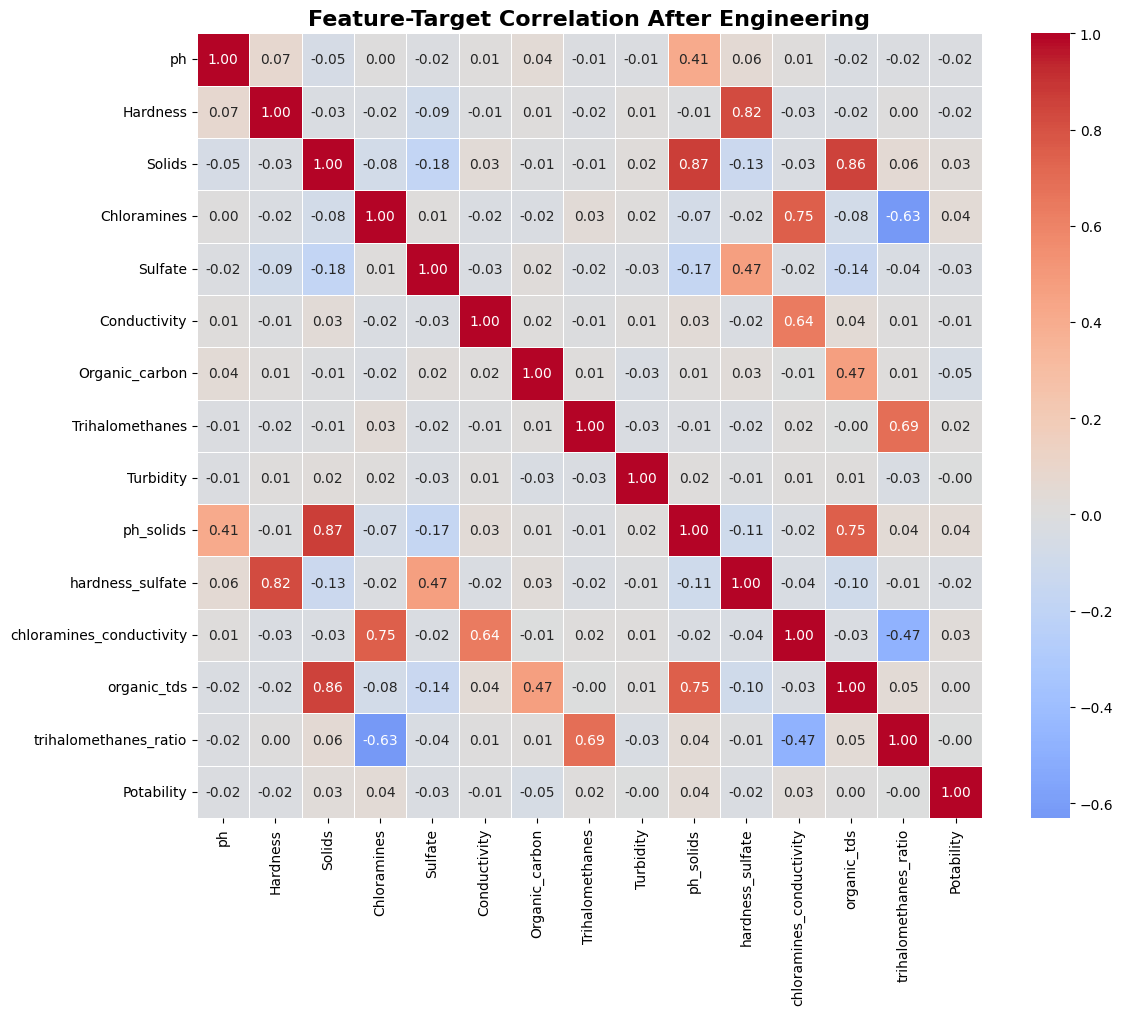

In [54]:
#feature correlation after engineering
plt.figure(figsize=(12, 10))
correlation_matrix = pd.concat([X_train_final, y_train_final], axis=1).corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Feature-Target Correlation After Engineering', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [55]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier


# Define base models
base_models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=5),
    'SVM': SVC(probability=True, random_state=42),
    'KNN': KNeighborsClassifier()
}
# Train and evaluate base models
base_results = {}

for name, model in base_models.items():
    print(f"\n Training {name}...")

    # Train the model using the prepared training data
    model.fit(X_train_final, y_train_final)

    # Make predictions on the test set
    y_pred = model.predict(X_test_final)
    y_pred_proba = model.predict_proba(X_test_final)[:, 1]

    # Calculate metrics
    base_results[name] = {
        'Accuracy': accuracy_score(y_test_final, y_pred),
        'Precision': precision_score(y_test_final, y_pred),
        'Recall': recall_score(y_test_final, y_pred),
        'F1-Score': f1_score(y_test_final, y_pred),
        'ROC-AUC': roc_auc_score(y_test_final, y_pred_proba)
    }

    print(f"   Accuracy: {base_results[name]['Accuracy']:.4f}")
    print(f"   F1-Score: {base_results[name]['F1-Score']:.4f}")
    print(f"   ROC-AUC: {base_results[name]['ROC-AUC']:.4f}")


 Training Logistic Regression...
   Accuracy: 0.5560
   F1-Score: 0.5573
   ROC-AUC: 0.5813

 Training Decision Tree...
   Accuracy: 0.5990
   F1-Score: 0.6697
   ROC-AUC: 0.6408

 Training SVM...
   Accuracy: 0.7485
   F1-Score: 0.7506
   ROC-AUC: 0.8239

 Training KNN...
   Accuracy: 0.8360
   F1-Score: 0.8435
   ROC-AUC: 0.9197


In [56]:
# Create base models comparison DataFrame
base_df = pd.DataFrame(base_results).T
base_df = base_df.sort_values('F1-Score', ascending=False)



In [57]:
display(base_df.round(4))

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
KNN,0.8360,0.8066,0.884,0.8435,0.9197
SVM,0.7485,0.7443,0.757,0.7506,0.8239
Decision Tree,0.5990,0.5693,0.813,0.6697,0.6408
Logistic Regression,0.5560,0.5557,0.559,0.5573,0.5813


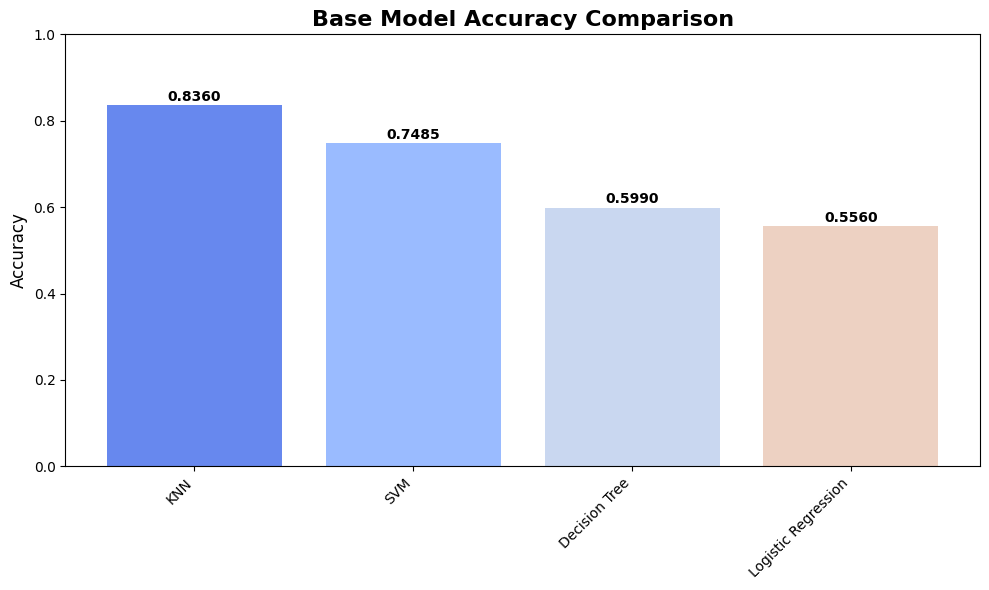

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

models = base_df.index
accuracies = base_df['Accuracy'].values

palette = sns.color_palette('coolwarm')
bars = plt.bar(models, accuracies, color=palette)

plt.title('Base Model Accuracy Comparison', fontsize=16, fontweight='bold')
plt.ylabel('Accuracy', fontsize=12)
plt.ylim([0, 1])
plt.xticks(rotation=45, ha='right')

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

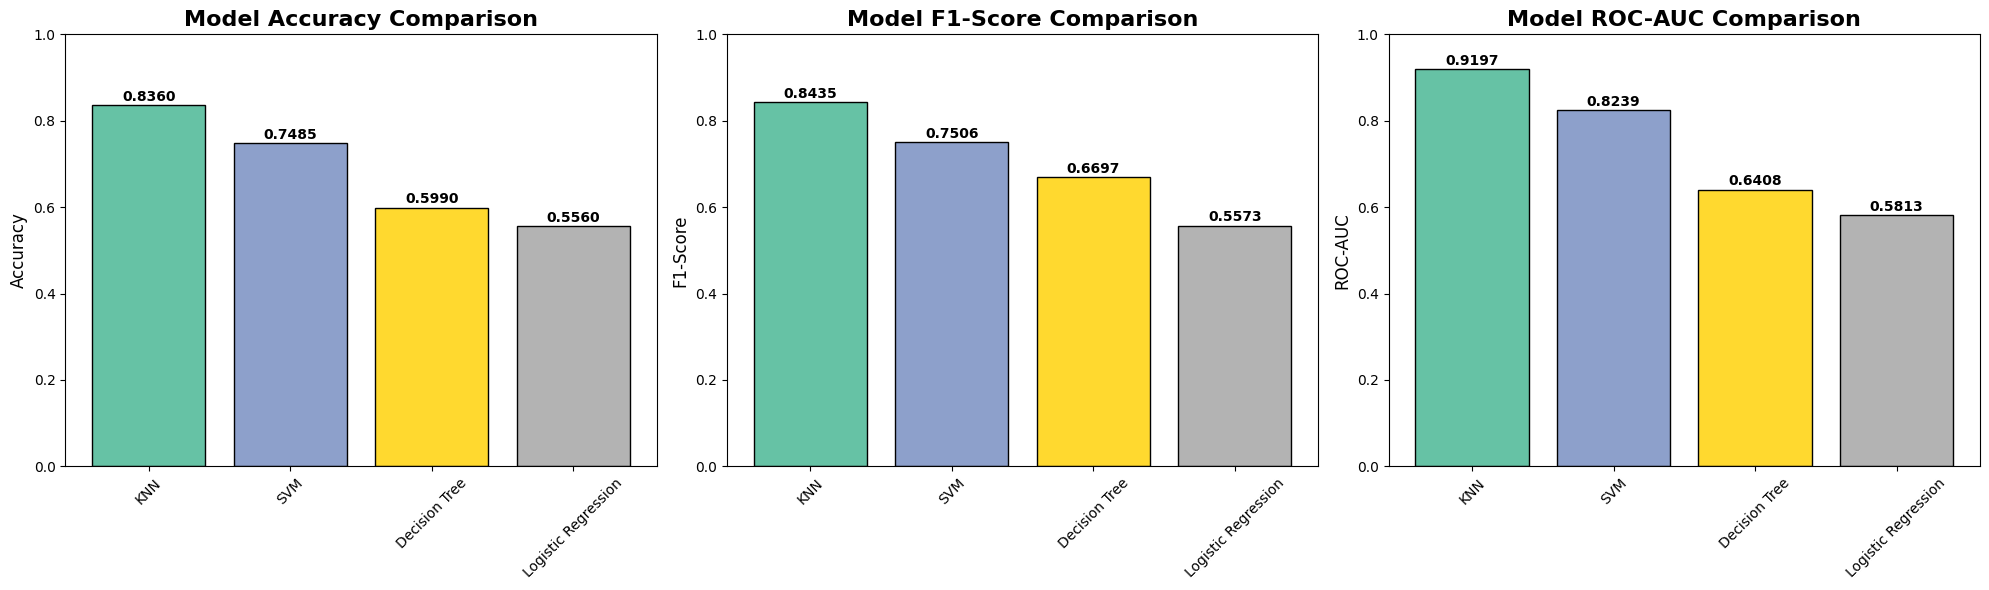

In [59]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Accuracy Comparison
models = base_df.index
accuracies = base_df['Accuracy'].values
colors = plt.cm.Set2(np.linspace(0, 1, len(models)))

bars1 = axes[0].bar(models, accuracies, color=colors, edgecolor='black')
axes[0].set_title('Model Accuracy Comparison', fontsize=16, fontweight='bold')
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylim([0, 1])
for bar, acc in zip(bars1, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                  f'{acc:.4f}', ha='center', fontweight='bold')

# 2. F1-Score Comparison
f1_scores = base_df['F1-Score'].values
bars2 = axes[1].bar(models, f1_scores, color=colors, edgecolor='black')
axes[1].set_title('Model F1-Score Comparison', fontsize=16, fontweight='bold')
axes[1].set_ylabel('F1-Score', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylim([0, 1])
for bar, f1 in zip(bars2, f1_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                  f'{f1:.4f}', ha='center', fontweight='bold')

# 3. ROC-AUC Comparison
roc_aucs = base_df['ROC-AUC'].values
bars3 = axes[2].bar(models, roc_aucs, color=colors, edgecolor='black')
axes[2].set_title('Model ROC-AUC Comparison', fontsize=16, fontweight='bold')
axes[2].set_ylabel('ROC-AUC', fontsize=12)
axes[2].tick_params(axis='x', rotation=45)
axes[2].set_ylim([0, 1])
for bar, auc_val in zip(bars3, roc_aucs):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                  f'{auc_val:.4f}', ha='center', fontweight='bold')



plt.tight_layout()
plt.show()

In [60]:
xgb_model = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=7,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    verbosity=0
)

# Train model
xgb_model.fit(X_train_final, y_train_final)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=0.1,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=7, max_leaves=None,
              min_child_weight=3, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=1000, n_jobs=None,
              num_parallel_tree=None, ...)

In [61]:
# Make predictions
xgb_pred = xgb_model.predict(X_test_final)
xgb_pred_proba = xgb_model.predict_proba(X_test_final)[:, 1]

In [62]:
# Calculate metrics
xgb_accuracy = accuracy_score(y_test_final, xgb_pred)
xgb_precision = precision_score(y_test_final, xgb_pred)
xgb_recall = recall_score(y_test_final, xgb_pred)
xgb_f1 = f1_score(y_test_final, xgb_pred)
xgb_auc = roc_auc_score(y_test_final, xgb_pred_proba)

In [63]:
print(f" XGBoost Performance:")
print(f"Accuracy: {xgb_accuracy:.4f} ({xgb_accuracy*100:.2f}%)")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall: {xgb_recall:.4f}")
print(f"F1-Score: {xgb_f1:.4f}")
print(f"ROC-AUC: {xgb_auc:.4f}")


 XGBoost Performance:
Accuracy: 0.9525 (95.25%)
Precision: 0.9380
Recall: 0.9690
F1-Score: 0.9533
ROC-AUC: 0.9896


In [64]:
# Cross-validation
xgb_cv_scores = cross_val_score(xgb_model, X_train_final, y_train_final, cv=5, scoring='accuracy')
print(f"Cross-Validation Accuracy: {xgb_cv_scores.mean():.4f} (+/- {xgb_cv_scores.std() * 2:.4f})")

Cross-Validation Accuracy: 0.9395 (+/- 0.0091)


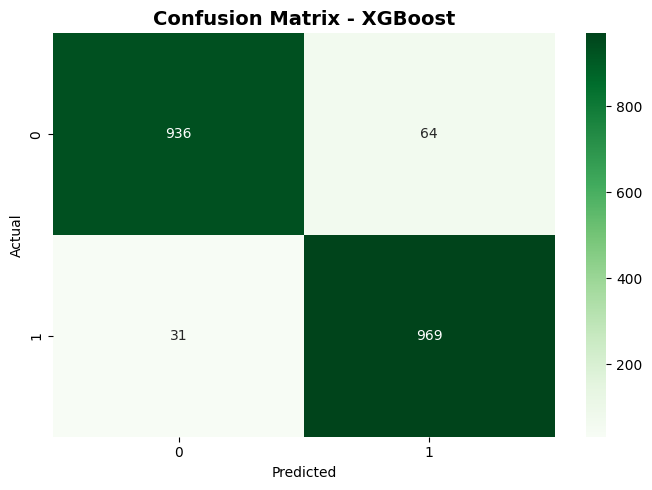

In [65]:
# Confusion Matrix
plt.figure(figsize=(7, 5))
cm_xgb = confusion_matrix(y_test_final, xgb_pred)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - XGBoost', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()


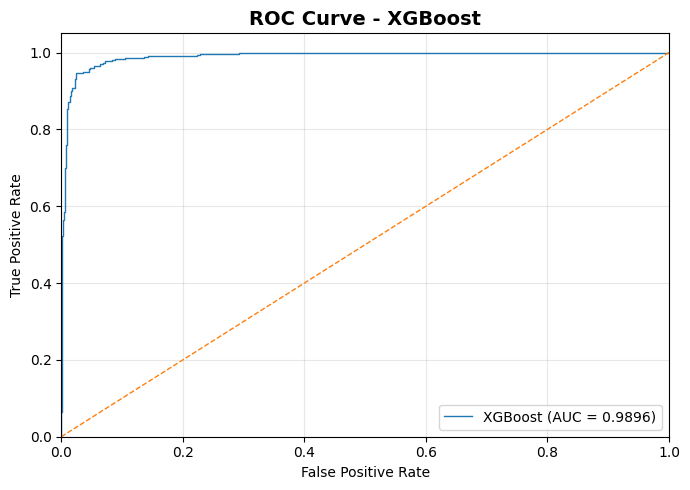

In [66]:
#ROC Curve - XGBoost
plt.figure(figsize=(7, 5))
fpr_xgb, tpr_xgb, _ = roc_curve(y_test_final, xgb_pred_proba)
auc_xgb = auc(fpr_xgb, tpr_xgb)

plt.plot(fpr_xgb, tpr_xgb, lw=1, label=f'XGBoost (AUC = {auc_xgb:.4f})')
plt.plot([0, 1], [0, 1], lw=1, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


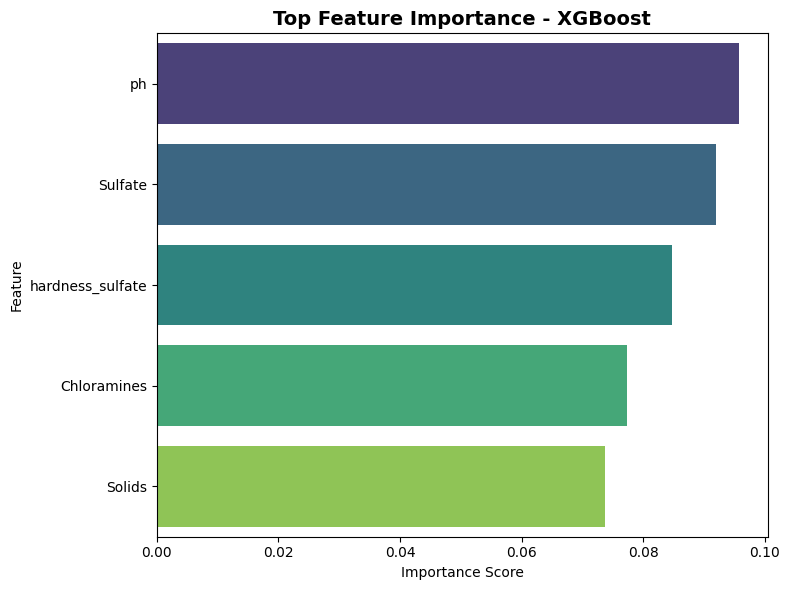

In [67]:
# Feature Importance - XGBoost
plt.figure(figsize=(8, 6))
feature_importance = pd.DataFrame({
    'feature': X_train_final.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False).head(5)

sns.barplot(data=feature_importance, x='importance', y='feature', palette='viridis')
plt.title('Top Feature Importance - XGBoost', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


In [68]:
print(" Classification Report:")
print(classification_report(y_test_final, xgb_pred))

 Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.94      0.95      1000
           1       0.94      0.97      0.95      1000

    accuracy                           0.95      2000
   macro avg       0.95      0.95      0.95      2000
weighted avg       0.95      0.95      0.95      2000



In [69]:
# Store XGBoost results
xgb_results = {
    'model': xgb_model,
    'accuracy': xgb_accuracy,
    'precision': xgb_precision,
    'recall': xgb_recall,
    'f1': xgb_f1,
    'auc': xgb_auc,
    'predictions': xgb_pred,
    'probabilities': xgb_pred_proba,
    'cv_score': xgb_cv_scores.mean()
}


**LightGBM**

In [70]:
lgb_model = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=7,
    num_leaves=31,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42,
    verbose=-1
)

# Train model
lgb_model.fit(X_train_final, y_train_final)


LGBMClassifier(colsample_bytree=0.8, learning_rate=0.05, max_depth=7,
               n_estimators=1000, random_state=42, reg_alpha=0.1,
               reg_lambda=0.1, subsample=0.8, verbose=-1)

In [71]:
# Make predictions
lgb_pred = lgb_model.predict(X_test_final)
lgb_pred_proba = lgb_model.predict_proba(X_test_final)[:, 1]


In [72]:
# Calculate metrics
lgb_accuracy = accuracy_score(y_test_final, lgb_pred)
lgb_precision = precision_score(y_test_final, lgb_pred)
lgb_recall = recall_score(y_test_final, lgb_pred)
lgb_f1 = f1_score(y_test_final, lgb_pred)
lgb_auc = roc_auc_score(y_test_final, lgb_pred_proba)

In [73]:
print(f"LightGBM Performance:")
print(f"Accuracy: {lgb_accuracy:.4f} ({lgb_accuracy*100:.2f}%)")
print(f"Precision: {lgb_precision:.4f}")
print(f"Recall: {lgb_recall:.4f}")
print(f"F1-Score: {lgb_f1:.4f}")
print(f"ROC-AUC: {lgb_auc:.4f}")

LightGBM Performance:
Accuracy: 0.9595 (95.95%)
Precision: 0.9518
Recall: 0.9680
F1-Score: 0.9598
ROC-AUC: 0.9901


In [74]:
# Cross-validation
lgb_cv_scores = cross_val_score(lgb_model, X_train_final, y_train_final, cv=5, scoring='accuracy')
print(f"Cross-Validation Accuracy: {lgb_cv_scores.mean():.4f} (+/- {lgb_cv_scores.std() * 2:.4f})")

Cross-Validation Accuracy: 0.9401 (+/- 0.0090)


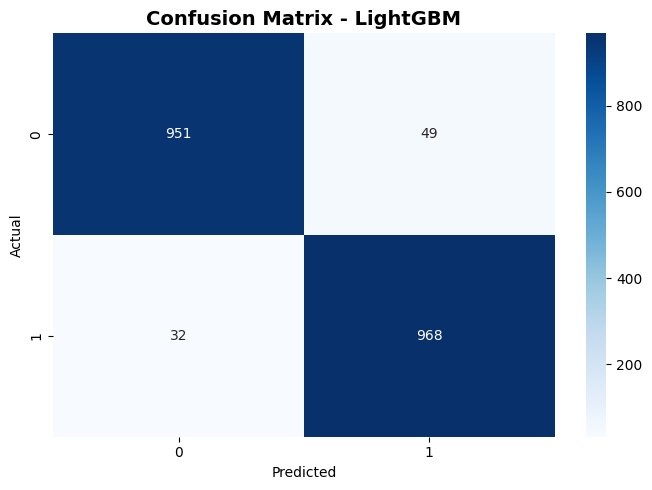

In [75]:
#Confusion Matrix - LightGBM
plt.figure(figsize=(7, 5))
cm_lgb = confusion_matrix(y_test_final, lgb_pred)
sns.heatmap(cm_lgb, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - LightGBM', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()


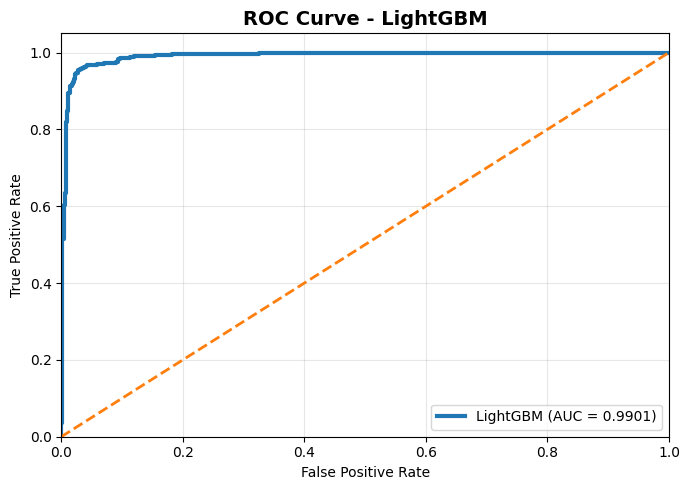

In [76]:
#ROC Curve - LightGBM
plt.figure(figsize=(7, 5))
fpr_lgb, tpr_lgb, _ = roc_curve(y_test_final, lgb_pred_proba)
auc_lgb = auc(fpr_lgb, tpr_lgb)

plt.plot(fpr_lgb, tpr_lgb, lw=3, label=f'LightGBM (AUC = {auc_lgb:.4f})')
plt.plot([0, 1], [0, 1], lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - LightGBM', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [77]:
# Store LightGBM results
lgb_results = {
    'model': lgb_model,
    'accuracy': lgb_accuracy,
    'precision': lgb_precision,
    'recall': lgb_recall,
    'f1': lgb_f1,
    'auc': lgb_auc,
    'predictions': lgb_pred,
    'probabilities': lgb_pred_proba,
    'cv_score': lgb_cv_scores.mean()
}


**Random forest**

In [78]:
rf_model = RandomForestClassifier(
    n_estimators=1000,
    random_state=42
)

# Train Random Forest model
rf_model.fit(X_train_final, y_train_final)

RandomForestClassifier(n_estimators=1000, random_state=42)

In [79]:
# Make predictions
rf_pred = rf_model.predict(X_test_final)
rf_pred_proba = rf_model.predict_proba(X_test_final)[:, 1]

In [80]:
# Calculate metrics
rf_accuracy = accuracy_score(y_test_final, rf_pred)
rf_precision = precision_score(y_test_final, rf_pred)
rf_recall = recall_score(y_test_final, rf_pred)
rf_f1 = f1_score(y_test_final, rf_pred)
rf_auc = roc_auc_score(y_test_final, rf_pred_proba)

In [81]:
print(f" Random Forest Classifier Performance:")
print(f"Accuracy: {rf_accuracy:.4f} ({rf_accuracy*100:.2f}%)")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall: {rf_recall:.4f}")
print(f"F1-Score: {rf_f1:.4f}")
print(f"ROC-AUC: {rf_auc:.4f}")

 Random Forest Classifier Performance:
Accuracy: 0.9630 (96.30%)
Precision: 0.9575
Recall: 0.9690
F1-Score: 0.9632
ROC-AUC: 0.9958


In [82]:
# Cross-validation
rf_cv_scores = cross_val_score(rf_model, X_train_final, y_train_final, cv=5, scoring='accuracy')
print(f"Cross-Validation Accuracy: {rf_cv_scores.mean():.4f} (+/- {rf_cv_scores.std() * 2:.4f})")


Cross-Validation Accuracy: 0.9445 (+/- 0.0164)


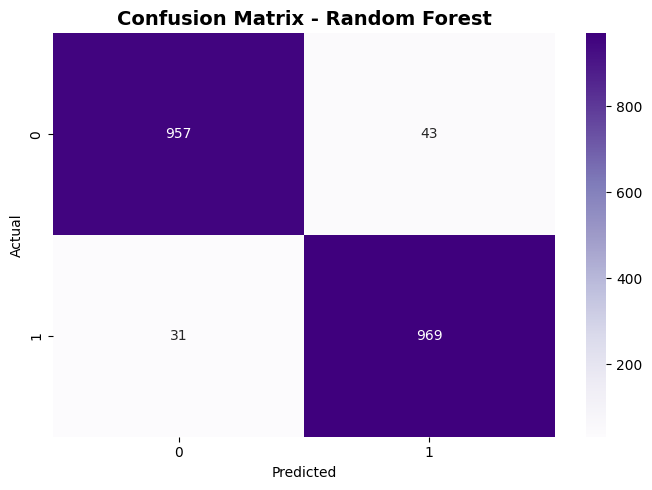

In [83]:
#Confusion Matrix - Random Forest
plt.figure(figsize=(7, 5))
cm_rf = confusion_matrix(y_test_final, rf_pred)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Purples')
plt.title('Confusion Matrix - Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()


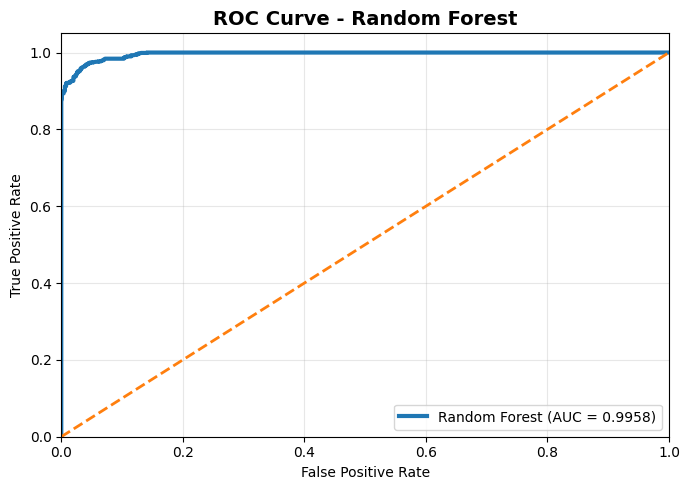

In [84]:
#ROC Curve - Random Forest
plt.figure(figsize=(7, 5))
fpr_rf, tpr_rf, _ = roc_curve(y_test_final, rf_pred_proba)
auc_rf = auc(fpr_rf, tpr_rf)

plt.plot(fpr_rf, tpr_rf, lw=3, label=f'Random Forest (AUC = {auc_rf:.4f})')
plt.plot([0, 1], [0, 1], lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


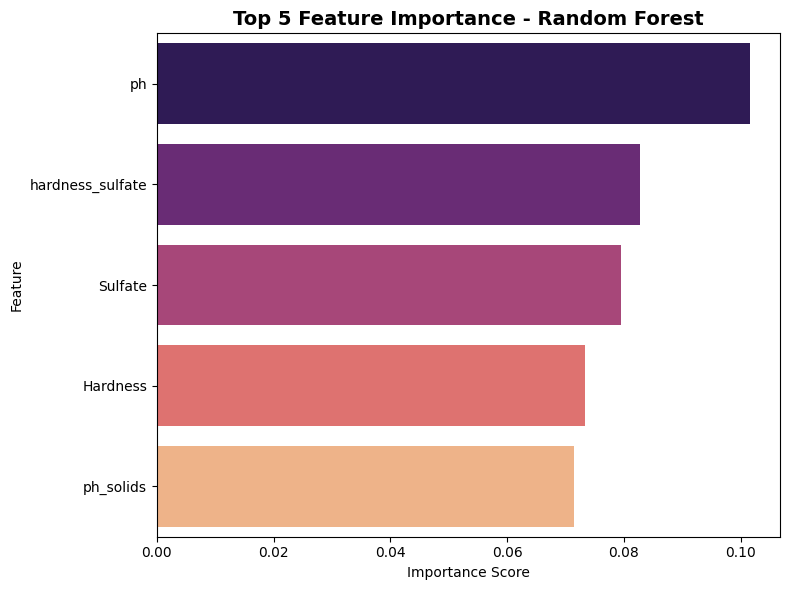

In [85]:
#Feature Importance - Random Forest
plt.figure(figsize=(8, 6))
feature_importance_rf = pd.DataFrame({
    'feature': X_train_final.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False).head(5)

sns.barplot(
    data=feature_importance_rf,
    x='importance',
    y='feature',
    palette='magma'
)

plt.title('Top 5 Feature Importance - Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


In [86]:
# Store Random Forest results
rf_results = {
    'model': rf_model,
    'accuracy': rf_accuracy,
    'precision': rf_precision,
    'recall': rf_recall,
    'f1': rf_f1,
    'auc': rf_auc,
    'predictions': rf_pred,
    'probabilities': rf_pred_proba,
    'cv_score': rf_cv_scores.mean()
}


In [87]:
# Install CatBoost if not available
try:
    from catboost import CatBoostClassifier
except:
    !pip install catboost
    from catboost import CatBoostClassifier

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 5.7 MB/s eta 0:00:00


In [88]:
advanced_base_estimators = [
    ('xgb', XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss'
    )),
    ('lgb', lgb.LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        random_state=42,
        verbose=-1
    )),
    ('cat', CatBoostClassifier(
        iterations=300,
        learning_rate=0.05,
        depth=6,
        random_state=42,
        verbose=False
    ))
]

# Define meta-learner with regularization
advanced_meta_learner = LogisticRegression(
    C=0.01,
    penalty='l2',
    solver='liblinear',
    random_state=42,
    max_iter=1000
)

# Create advanced stacking classifier
advanced_stacking_model = StackingClassifier(
    estimators=advanced_base_estimators,
    final_estimator=advanced_meta_learner,
    cv=5,
    stack_method='predict_proba',
    passthrough=True
)


In [89]:
# Train advanced stacking model
advanced_stacking_model.fit(X_train_final, y_train_final)

StackingClassifier(cv=5,
                   estimators=[('xgb',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=None,
                                              device=None,
                                              early_stopping_rounds=None,
                                              enable_categorical=False,
                                              eval_metric='logloss',
                                              feature_types=None,
                                              feature_weights=None, gamma=None,
                                              grow_policy=None,
                                              importance_type=None,
                                              interac...
                                              n_estimators=300, n_jobs=None,
                                              num_parallel_tree=None, ...)),
                               ('lgb',
                                LGBMClassifier(learning_rate=0.05, max_depth=6,
                                               n_estimators=300,
                                               random_state=42, verbose=-1)),
                               ('cat',
                                <catboost.core.CatBoostClassifier object at 0x7a8fac9ce0c0>)],
                   final_estimator=LogisticRegression(C=0.01, max_iter=1000,
                                                      random_state=42,
                                                      solver='liblinear'),
                   passthrough=True, stack_method='predict_proba')

In [90]:
# Make predictions
advanced_stacking_pred = advanced_stacking_model.predict(X_test_final)
advanced_stacking_pred_proba = advanced_stacking_model.predict_proba(X_test_final)[:, 1]

In [91]:
# Calculate metrics
advanced_stacking_accuracy = accuracy_score(y_test_final, advanced_stacking_pred)
advanced_stacking_precision = precision_score(y_test_final, advanced_stacking_pred)
advanced_stacking_recall = recall_score(y_test_final, advanced_stacking_pred)
advanced_stacking_f1 = f1_score(y_test_final, advanced_stacking_pred)
advanced_stacking_auc = roc_auc_score(y_test_final, advanced_stacking_pred_proba)

In [92]:
print(f"Advanced Stacking Performance:")
print(f"Accuracy: {advanced_stacking_accuracy:.4f} ({advanced_stacking_accuracy*100:.2f}%)")
print(f"Precision: {advanced_stacking_precision:.4f}")
print(f"Recall: {advanced_stacking_recall:.4f}")
print(f"F1-Score: {advanced_stacking_f1:.4f}")
print(f"ROC-AUC: {advanced_stacking_auc:.4f}")

Advanced Stacking Performance:
Accuracy: 0.8940 (89.40%)
Precision: 0.8731
Recall: 0.9220
F1-Score: 0.8969
ROC-AUC: 0.9662


In [93]:
# Cross-validation
advanced_stacking_cv_scores = cross_val_score(advanced_stacking_model, X_train_final, y_train_final, cv=5, scoring='accuracy')
print(f"Cross-Validation Accuracy: {advanced_stacking_cv_scores.mean():.4f} (+/- {advanced_stacking_cv_scores.std() * 2:.4f})")


Cross-Validation Accuracy: 0.9005 (+/- 0.0186)


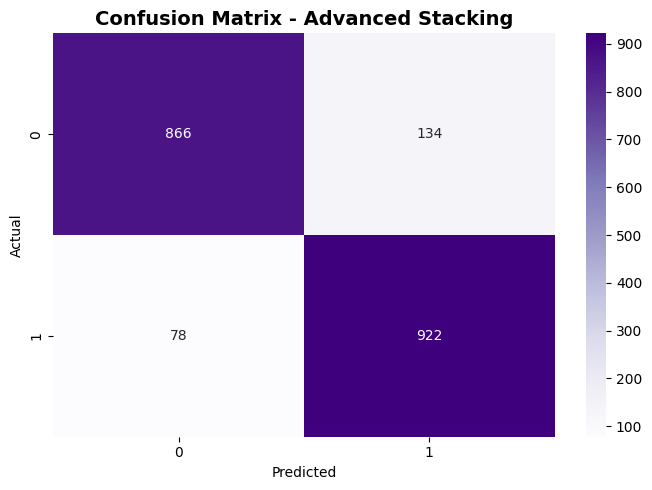

In [94]:
#Confusion Matrix - Advanced Stacking
plt.figure(figsize=(7, 5))
cm_advanced_stacking = confusion_matrix(y_test_final, advanced_stacking_pred)
sns.heatmap(cm_advanced_stacking, annot=True, fmt='d', cmap='Purples')
plt.title('Confusion Matrix - Advanced Stacking', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()


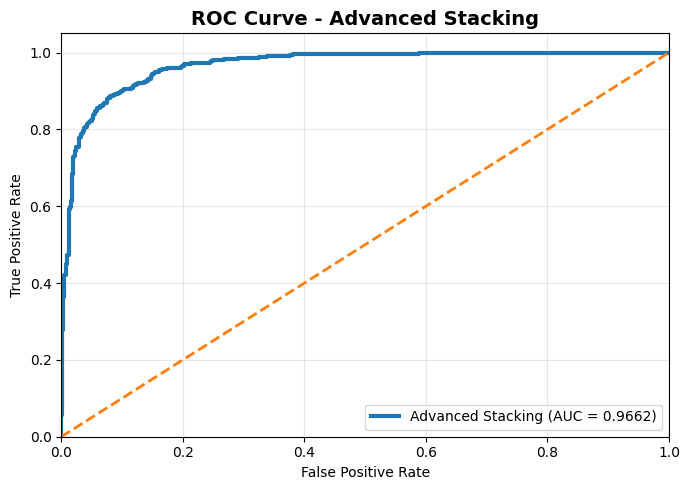

In [95]:
#ROC Curve - Advanced Stacking
plt.figure(figsize=(7, 5))
fpr_advanced_stacking, tpr_advanced_stacking, _ = roc_curve(
    y_test_final, advanced_stacking_pred_proba
)
auc_advanced_stacking = auc(fpr_advanced_stacking, tpr_advanced_stacking)

plt.plot(
    fpr_advanced_stacking,
    tpr_advanced_stacking,
    lw=3,
    label=f'Advanced Stacking (AUC = {auc_advanced_stacking:.4f})'
)
plt.plot([0, 1], [0, 1], lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Advanced Stacking', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [96]:
# Store advanced stacking results
advanced_stacking_results = {
    'model': advanced_stacking_model,
    'accuracy': advanced_stacking_accuracy,
    'precision': advanced_stacking_precision,
    'recall': advanced_stacking_recall,
    'f1': advanced_stacking_f1,
    'auc': advanced_stacking_auc,
    'predictions': advanced_stacking_pred,
    'probabilities': advanced_stacking_pred_proba,
    'cv_score': advanced_stacking_cv_scores.mean()
}


**voting classifier**

In [97]:
# Create individual models for voting
models_for_voting = [
    ('xgb', XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss'
    )),
    ('lgb', lgb.LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        random_state=42,
        verbose=-1
    )),
    ('rf', RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        random_state=42
    )),
    ('lr', LogisticRegression(
        C=0.1,
        random_state=42,
        max_iter=1000
    ))
]

In [98]:
# Create hard voting classifier
hard_voting_model = VotingClassifier(
    estimators=models_for_voting,
    voting='hard'
)

# Create soft voting classifier
soft_voting_model = VotingClassifier(
    estimators=models_for_voting,
    voting='soft'
)

# Train both models
print("\nTraining Hard Voting Classifier...")
hard_voting_model.fit(X_train_final, y_train_final)

print("Training Soft Voting Classifier...")
soft_voting_model.fit(X_train_final, y_train_final)


Training Hard Voting Classifier...
Training Soft Voting Classifier...


VotingClassifier(estimators=[('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric='logloss',
                                            feature_types=None,
                                            feature_weights=None, gamma=None,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_co...
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=300, n_jobs=None,
                                            num_parallel_tree=None, ...)),
                             ('lgb',
                              LGBMClassifier(learning_rate=0.05, max_depth=6,
                                             n_estimators=300, random_state=42,
                                             verbose=-1)),
                             ('rf',
                              RandomForestClassifier(max_depth=10,
                                                     n_estimators=300,
                                                     random_state=42)),
                             ('lr',
                              LogisticRegression(C=0.1, max_iter=1000,
                                                 random_state=42))],
                 voting='soft')

In [99]:
# Make predictions
hard_voting_pred = hard_voting_model.predict(X_test_final)
soft_voting_pred = soft_voting_model.predict(X_test_final)
soft_voting_pred_proba = soft_voting_model.predict_proba(X_test_final)[:, 1]

In [100]:
# Calculate metrics
hard_voting_accuracy = accuracy_score(y_test_final, hard_voting_pred)
soft_voting_accuracy = accuracy_score(y_test_final, soft_voting_pred)
soft_voting_precision = precision_score(y_test_final, soft_voting_pred)
soft_voting_recall = recall_score(y_test_final, soft_voting_pred)
soft_voting_f1 = f1_score(y_test_final, soft_voting_pred)
soft_voting_auc = roc_auc_score(y_test_final, soft_voting_pred_proba)

In [101]:
print(f" Voting Classifier Performance:")
print(f"Hard Voting Accuracy: {hard_voting_accuracy:.4f} ({hard_voting_accuracy*100:.2f}%)")
print(f"Soft Voting Accuracy: {soft_voting_accuracy:.4f} ({soft_voting_accuracy*100:.2f}%)")
print(f"Soft Voting Precision: {soft_voting_precision:.4f}")
print(f"Soft Voting Recall: {soft_voting_recall:.4f}")
print(f"Soft Voting F1-Score: {soft_voting_f1:.4f}")
print(f"Soft Voting ROC-AUC: {soft_voting_auc:.4f}")

 Voting Classifier Performance:
Hard Voting Accuracy: 0.8950 (89.50%)
Soft Voting Accuracy: 0.9065 (90.65%)
Soft Voting Precision: 0.9102
Soft Voting Recall: 0.9020
Soft Voting F1-Score: 0.9061
Soft Voting ROC-AUC: 0.9670


In [102]:
# Cross-validation for soft voting
soft_voting_cv_scores = cross_val_score(soft_voting_model, X_train_final, y_train_final, cv=5, scoring='accuracy')
print(f"Soft Voting Cross-Validation Accuracy: {soft_voting_cv_scores.mean():.4f} (+/- {soft_voting_cv_scores.std() * 2:.4f})")


Soft Voting Cross-Validation Accuracy: 0.9064 (+/- 0.0224)


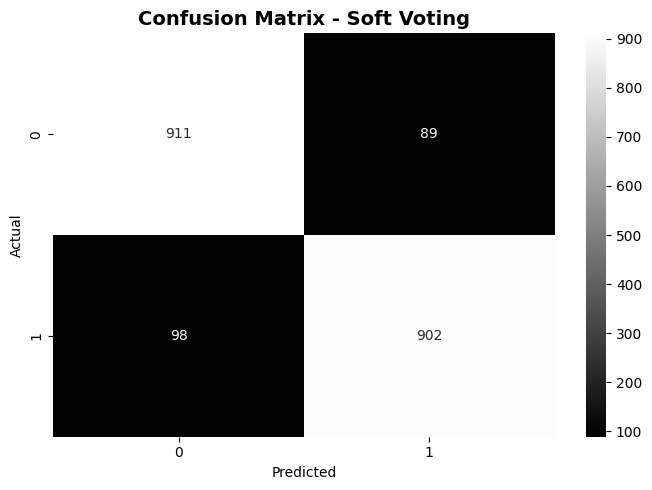

In [103]:
#Confusion Matrix - Soft Voting
plt.figure(figsize=(7, 5))
cm_soft_voting = confusion_matrix(y_test_final, soft_voting_pred)
sns.heatmap(cm_soft_voting, annot=True, fmt='d', cmap='grey')
plt.title('Confusion Matrix - Soft Voting', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()


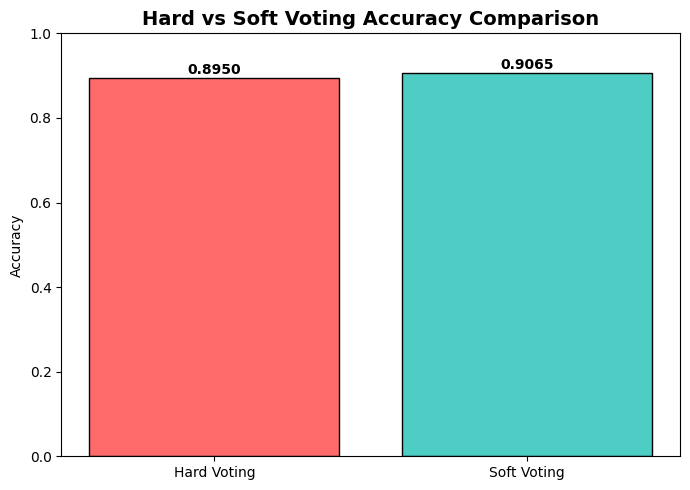

In [104]:
#Hard vs Soft Voting Accuracy Comparison
plt.figure(figsize=(7, 5))

voting_types = ['Hard Voting', 'Soft Voting']
voting_accuracies = [hard_voting_accuracy, soft_voting_accuracy]
colors = ['#ff6b6b', '#4ecdc4']

bars = plt.bar(voting_types, voting_accuracies, color=colors, edgecolor='black')
plt.title('Hard vs Soft Voting Accuracy Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy')
plt.ylim([0, 1])

for bar, acc in zip(bars, voting_accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f'{acc:.4f}',
        ha='center',
        fontweight='bold'
    )

plt.tight_layout()
plt.show()


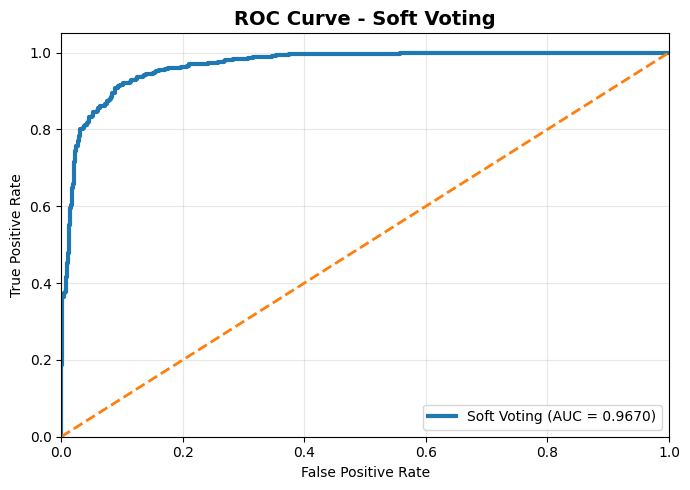

In [105]:
#ROC Curve - Soft Voting
plt.figure(figsize=(7, 5))
fpr_soft_voting, tpr_soft_voting, _ = roc_curve(
    y_test_final, soft_voting_pred_proba
)
auc_soft_voting = auc(fpr_soft_voting, tpr_soft_voting)

plt.plot(
    fpr_soft_voting,
    tpr_soft_voting,
    lw=3,
    label=f'Soft Voting (AUC = {auc_soft_voting:.4f})'
)
plt.plot([0, 1], [0, 1], lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Soft Voting', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [106]:
# Store voting results
voting_results = {
    'hard_model': hard_voting_model,
    'soft_model': soft_voting_model,
    'hard_accuracy': hard_voting_accuracy,
    'soft_accuracy': soft_voting_accuracy,
    'soft_precision': soft_voting_precision,
    'soft_recall': soft_voting_recall,
    'soft_f1': soft_voting_f1,
    'soft_auc': soft_voting_auc,
    'predictions': soft_voting_pred,
    'probabilities': soft_voting_pred_proba,
    'cv_score': soft_voting_cv_scores.mean()
}


**Model Comparison and Analysis**

In [107]:
# Collect all results
all_results = {
    'XGBoost': {
        'Accuracy': xgb_results['accuracy'],
        'Precision': xgb_results['precision'],
        'Recall': xgb_results['recall'],
        'F1-Score': xgb_results['f1'],
        'ROC-AUC': xgb_results['auc'],
        'CV Score': xgb_results['cv_score']
    },
    'LightGBM': {
        'Accuracy': lgb_results['accuracy'],
        'Precision': lgb_results['precision'],
        'Recall': lgb_results['recall'],
        'F1-Score': lgb_results['f1'],
        'ROC-AUC': lgb_results['auc'],
        'CV Score': lgb_results['cv_score']
    },

    'Random forest': {
        'Accuracy': rf_results['accuracy'],
        'Precision': rf_results['precision'],
        'Recall': rf_results['recall'],
        'F1-Score': rf_results['f1'],
        'ROC-AUC': rf_results['auc'],
        'CV Score': rf_results['cv_score']
    },
    'Stacking (Advanced)': {
        'Accuracy': advanced_stacking_results['accuracy'],
        'Precision': advanced_stacking_results['precision'],
        'Recall': advanced_stacking_results['recall'],
        'F1-Score': advanced_stacking_results['f1'],
        'ROC-AUC': advanced_stacking_results['auc'],
        'CV Score': advanced_stacking_results['cv_score']
    },
    'Voting (Soft)': {
        'Accuracy': voting_results['soft_accuracy'],
        'Precision': voting_results['soft_precision'],
        'Recall': voting_results['soft_recall'],
        'F1-Score': voting_results['soft_f1'],
        'ROC-AUC': voting_results['soft_auc'],
        'CV Score': voting_results['cv_score']
    }
}

In [108]:
# Create comparison DataFrame
comparison_df = pd.DataFrame(all_results).T
comparison_df = comparison_df.sort_values('Accuracy', ascending=False)


In [109]:
print("PERFORMANCE COMPARISON TABLE:")
display(comparison_df.round(4))


PERFORMANCE COMPARISON TABLE:


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,CV Score
Random forest,0.9630,0.9575,0.969,0.9632,0.9958,0.9445
LightGBM,0.9595,0.9518,0.968,0.9598,0.9901,0.9401
XGBoost,0.9525,0.9380,0.969,0.9533,0.9896,0.9395
Voting (Soft),0.9065,0.9102,0.902,0.9061,0.9670,0.9064
Stacking (Advanced),0.8940,0.8731,0.922,0.8969,0.9662,0.9005


In [110]:
# Find best model
best_model_name = comparison_df.index[0]
best_model_metrics = comparison_df.iloc[0]
print(f"BEST PERFORMING MODEL: {best_model_name}")
print(f"   Accuracy: {best_model_metrics['Accuracy']:.4f} ({best_model_metrics['Accuracy']*100:.2f}%)")
print(f"   F1-Score: {best_model_metrics['F1-Score']:.4f}")
print(f"   ROC-AUC: {best_model_metrics['ROC-AUC']:.4f}")
print(f"   Cross-Validation Score: {best_model_metrics['CV Score']:.4f}")

BEST PERFORMING MODEL: Random forest
   Accuracy: 0.9630 (96.30%)
   F1-Score: 0.9632
   ROC-AUC: 0.9958
   Cross-Validation Score: 0.9445


In [111]:
base_models_formatted_results = {}
for name, metrics in base_results.items():
    base_models_formatted_results[name] = {
        'Accuracy': metrics['Accuracy'],
        'Precision': metrics['Precision'],
        'Recall': metrics['Recall'],
        'F1-Score': metrics['F1-Score'],
        'ROC-AUC': metrics['ROC-AUC'],
        'CV Score': np.nan # Base models might not have an explicit CV score in `base_results`
    }

In [112]:
# Combine with existing ensemble results
combined_all_results = {**all_results, **base_models_formatted_results}

# Create comparison DataFrame
combined_comparison_df = pd.DataFrame(combined_all_results).T
combined_comparison_df = combined_comparison_df.sort_values('Accuracy', ascending=False)

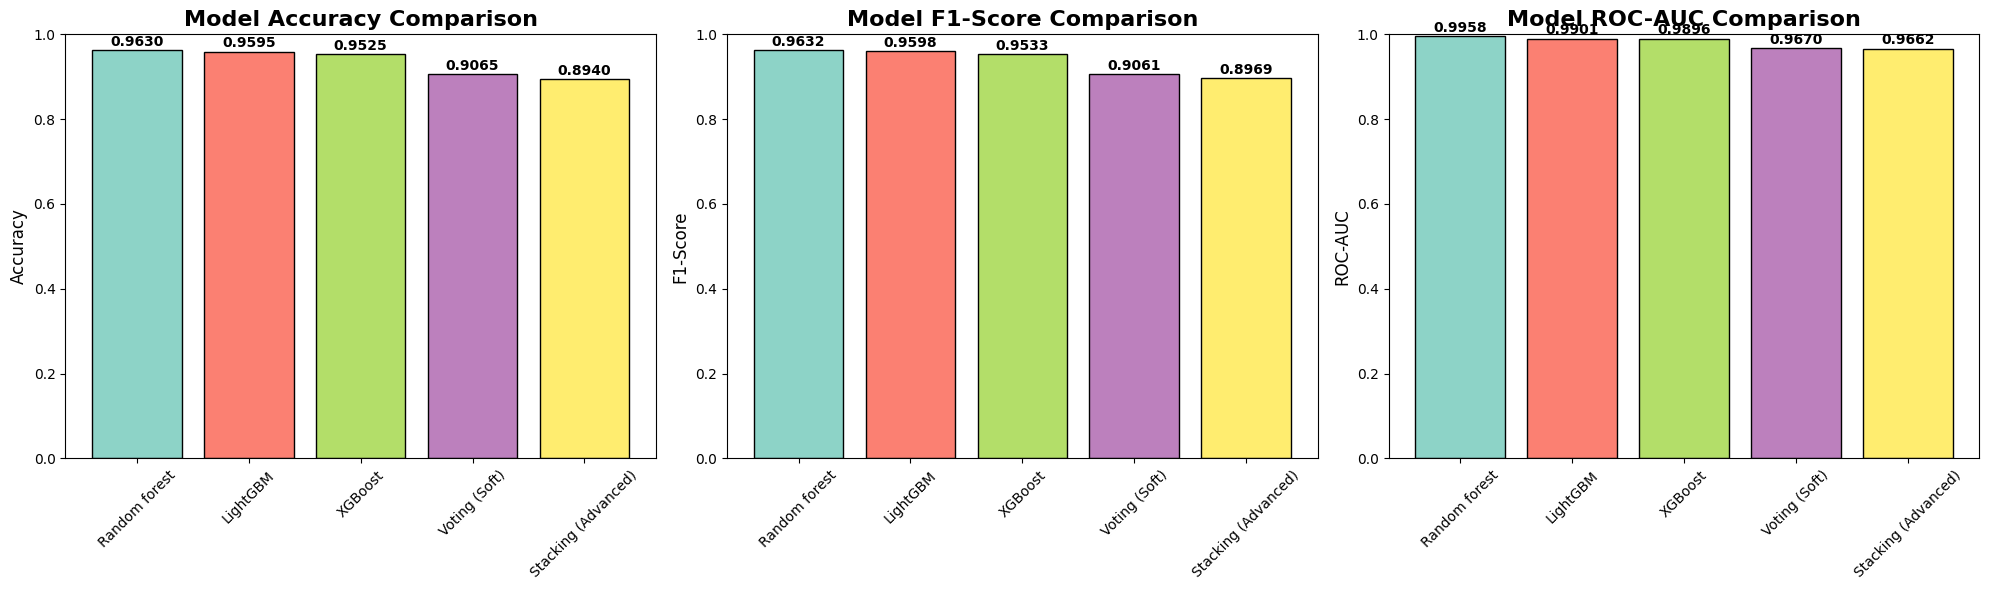

In [113]:
# Step 12: Visual Comparison Dashboard
# --------------------------------------------------
# This code creates a comprehensive visual comparison

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Accuracy Comparison
models = comparison_df.index
accuracies = comparison_df['Accuracy'].values
colors = plt.cm.Set3(np.linspace(0, 1, len(models)))

bars1 = axes[0].bar(models, accuracies, color=colors, edgecolor='black')
axes[0].set_title('Model Accuracy Comparison', fontsize=16, fontweight='bold')
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylim([0, 1])
for bar, acc in zip(bars1, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                  f'{acc:.4f}', ha='center', fontweight='bold')

# 2. F1-Score Comparison
f1_scores = comparison_df['F1-Score'].values
bars2 = axes[1].bar(models, f1_scores, color=colors, edgecolor='black')
axes[1].set_title('Model F1-Score Comparison', fontsize=16, fontweight='bold')
axes[1].set_ylabel('F1-Score', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylim([0, 1])
for bar, f1 in zip(bars2, f1_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                  f'{f1:.4f}', ha='center', fontweight='bold')

# 3. ROC-AUC Comparison
roc_aucs = comparison_df['ROC-AUC'].values
bars3 = axes[2].bar(models, roc_aucs, color=colors, edgecolor='black')
axes[2].set_title('Model ROC-AUC Comparison', fontsize=16, fontweight='bold')
axes[2].set_ylabel('ROC-AUC', fontsize=12)
axes[2].tick_params(axis='x', rotation=45)
axes[2].set_ylim([0, 1])
for bar, auc_val in zip(bars3, roc_aucs):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                  f'{auc_val:.4f}', ha='center', fontweight='bold')



plt.tight_layout()
plt.show()

In [114]:
import ipywidgets as widgets
from IPython.display import display, HTML

trained_models = {
    'Random Forest': rf_model
}

def predict_water_potability(input_params_dict):
    """
    Function to predict water potability using specified models.
    Applies feature engineering and scaling to the input data.
    """
    # Convert input dictionary to DataFrame
    input_df = pd.DataFrame([input_params_dict])

    # 1. Impute missing values (if any, though user input should be complete)
    #    Use the global imputer fitted during preprocessing
    input_imputed = imputer.transform(input_df)
    input_imputed_df = pd.DataFrame(input_imputed, columns=input_df.columns)

    # 2. Feature Engineering
    #    Apply the same feature engineering steps as done during training
    input_engineered = input_imputed_df.copy()
    input_engineered['ph_solids'] = input_engineered['ph'] * input_engineered['Solids']
    input_engineered['hardness_sulfate'] = input_engineered['Hardness'] * input_engineered['Sulfate']
    input_engineered['chloramines_conductivity'] = input_engineered['Chloramines'] * input_engineered['Conductivity']
    input_engineered['organic_tds'] = input_engineered['Organic_carbon'] * input_engineered['Solids'] / 1000
    input_engineered['trihalomethanes_ratio'] = input_engineered['Trihalomethanes'] / (input_engineered['Chloramines'] + 1)

    # 3. Scaling
    #    Use the global scaler fitted during preprocessing
    input_processed_df = scaler.transform(input_engineered)
    input_processed_df = pd.DataFrame(input_processed_df, columns=input_engineered.columns)

    results_html = "<h3>PREDICTION RESULTS:</h3><hr>"

    # Get predictions from all selected models
    for model_name, model in trained_models.items():
        prediction = model.predict(input_processed_df)[0]
        probability = model.predict_proba(input_processed_df)[0]
        result_text = "POTABLE " if prediction == 1 else "NOT POTABLE "
        confidence = probability[prediction]
        results_html += f"<p><b>{model_name}:</b> {result_text} (Confidence: {confidence:.1%})</p>"

    return results_html

In [115]:
# --- Dashboard Setup ---
print("Water Potability Prediction Dashboard")
print("="*60)

# Input Widgets
ph_widget = widgets.FloatText(description='pH Level (0-14):', value=7.0, min=0.0, max=14.0, step=1)
hardness_widget = widgets.FloatText(description='Hardness (mg/L):', value=150.0, min=0.0, step=1)
solids_widget = widgets.FloatText(description='TDS (ppm):', value=20000.0, min=0.0, step=1)
chloramines_widget = widgets.FloatText(description='Chloramines (ppm):', value=7.0, min=0.0, step=1)
sulfate_widget = widgets.FloatText(description='Sulfate (mg/L):', value=300.0, min=0.0, step=1)
conductivity_widget = widgets.FloatText(description='Conductivity (μS/cm):', value=400.0, min=0.0, step=1)
organic_carbon_widget = widgets.FloatText(description='Organic Carbon (ppm):', value=10.0, min=0.0, step=1)
trihalomethanes_widget = widgets.FloatText(description='Trihalomethanes (μg/L):', value=70.0, min=0.0, step=1)
turbidity_widget = widgets.FloatText(description='Turbidity (NTU):', value=3.0, min=0.0, step=1)

predict_button = widgets.Button(description='Predict Potability', button_style='success')
output_area = widgets.Output()

# Arrange input widgets
input_widgets_layout = widgets.VBox([
    ph_widget,
    hardness_widget,
    solids_widget,
    chloramines_widget,
    sulfate_widget,
    conductivity_widget,
    organic_carbon_widget,
    trihalomethanes_widget,
    turbidity_widget
])

# Function to handle button click
def on_predict_button_clicked(b):
    with output_area:
        output_area.clear_output()
        input_params = {
            'ph': ph_widget.value,
            'Hardness': hardness_widget.value,
            'Solids': solids_widget.value,
            'Chloramines': chloramines_widget.value,
            'Sulfate': sulfate_widget.value,
            'Conductivity': conductivity_widget.value,
            'Organic_carbon': organic_carbon_widget.value,
            'Trihalomethanes': trihalomethanes_widget.value,
            'Turbidity': turbidity_widget.value
        }
        prediction_results_html = predict_water_potability(input_params)
        display(HTML(prediction_results_html))

predict_button.on_click(on_predict_button_clicked)

# Display the dashboard
display(input_widgets_layout, predict_button, output_area)

Water Potability Prediction Dashboard


Button(button_style='success', description='Predict Potability', style=ButtonStyle())

Output()